In [2]:
%load_ext autoreload
%autoreload 2

In [16]:
import sys
sys.path.append("../")
import pandas as pd
from utils import ca as cu, behave as bu, plot as pu, db as db
import numpy as np
from paths.config import M2PConfig
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import ranksums, spearmanr, skewnorm
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ranksums, wilcoxon
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
import patsy
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from scipy.stats import randint, uniform
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import gaussian_filter1d
#from xgboost import XGBClassifier
#import lightgbm as lgb

In [4]:
COLOR_PENK = (0, 0, 1, 1)
COLOR_NONPENK = (1, 0, 0, 1)

LINEWIDTH_HIST = 3
LINEWIDTH_FIT = 3

COL_EXP_ROI_ID = 'exp_roi_id'
COL_ABS_ROT = bu.AHV_FILT_GRAD + "-ABS"

COL_HEADING_EGO_SIN = bu.HEADING_EGO_ABS + "-COS"
COL_HEADING_EGO_COS = bu.HEADING_EGO_ABS + "-SIN"
COL_HEADING_ALLO_SIN = bu.HEADING_ALLO_ABS + "-COS"
COL_HEADING_ALLO_COS = bu.HEADING_ALLO_ABS + "-SIN"
COL_HD_COS = bu.HD_ABS_FILT + "-COS"
COL_HD_SIN = bu.HD_ABS_FILT + "-SIN"

COL_IS_ROT = "IS-ROT"
COL_IS_TRANS = "IS-TRANS"
COL_IS_LOCO = "IS-LOCO"
COL_IS_MOVING = "IS-MOVING"
COL_DIST_TRAV = "distance-travelled"




In [5]:
cfg = M2PConfig()
df_exps, df_roi, df_ca, df_behave, df_behave_ca = db.get_ca_behave_data(cfg, 
                                                                        exclude_bad_behave=True,
                                                                        exclude_bad_2p=True, 
                                                                        roi_type=None,
                                                                        #max_speed=20,
                                                                        #max_ahv_abs=300,
                                                                        min_ear_dist=None,
                                                                        max_ear_dist=40,
                                                                        )



df_behave_ca[COL_EXP_ROI_ID] = df_behave_ca['exp_id'] + "-" + str(df_behave_ca['roi_id'])

df_behave_ca[COL_ABS_ROT] = df_behave_ca[bu.AHV_FILT_GRAD].abs()
df_behave_ca[COL_IS_ROT] = bu.get_ahv_indexes(df_behave_ca)
df_behave_ca[COL_IS_TRANS] = bu.get_trans_indexes(df_behave_ca)
df_behave_ca[COL_IS_MOVING] = bu.get_moving_indexes(df_behave_ca)
df_behave_ca[COL_IS_LOCO] = bu.get_loco_indexes(df_behave_ca)

df_behave_ca[COL_HD_SIN] = np.sin(np.radians(df_behave_ca[bu.HD_ABS_FILT]))
df_behave_ca[COL_HD_COS] = np.cos(np.radians(df_behave_ca[bu.HD_ABS_FILT]))
df_behave_ca[COL_HEADING_EGO_SIN] = np.sin(np.radians(df_behave_ca[bu.HEADING_EGO_ABS]))
df_behave_ca[COL_HEADING_EGO_COS] = np.cos(np.radians(df_behave_ca[bu.HEADING_EGO_ABS]))
df_behave_ca[COL_HEADING_ALLO_SIN] = np.sin(np.radians(df_behave_ca[bu.HEADING_ALLO_ABS]))
df_behave_ca[COL_HEADING_ALLO_COS] = np.cos(np.radians(df_behave_ca[bu.HEADING_ALLO_ABS]))

Excluded 26221 bad 2p frames 0.54%
Bad behave - excluded 39127 bad behave frames 20.11%
Max ear dist - excluded 4542 bad behave frames 2.92%


# Decode

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 16, 19, 20, 21, 28, 13, 17, 18, 25, 29, 40, 43, 44, 48, 52, 54, 56, 57, 60, 61, 66, 69, 74, 78, 86, 90, 106, 111, 141]
(9514, 41)
(9514, 41)
(952, 41)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'max_depth': 7, 'max_features': 0.013264961159866528, 'min_samples_leaf': 9, 'min_samples_split': 3, 'n_estimators': 314}
Best r2 score: -0.0222
1114353
Test R2 score: 0.0039


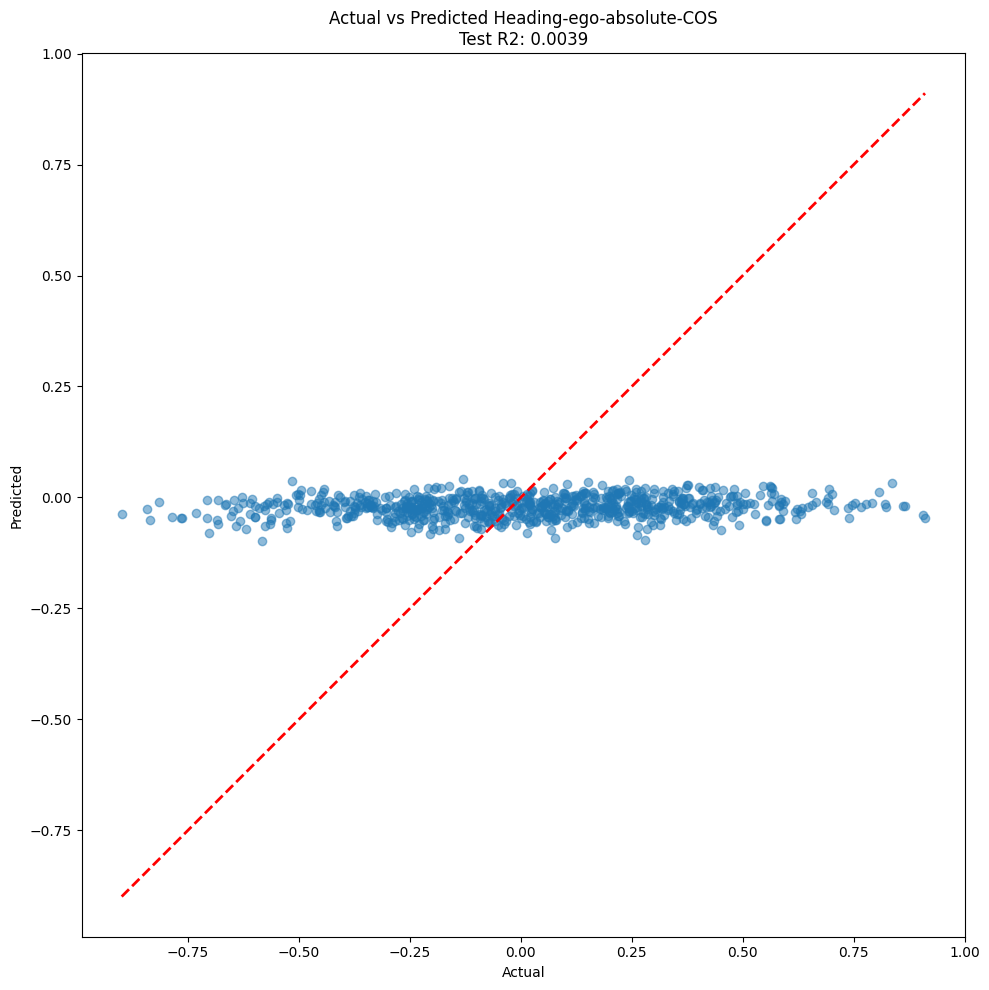

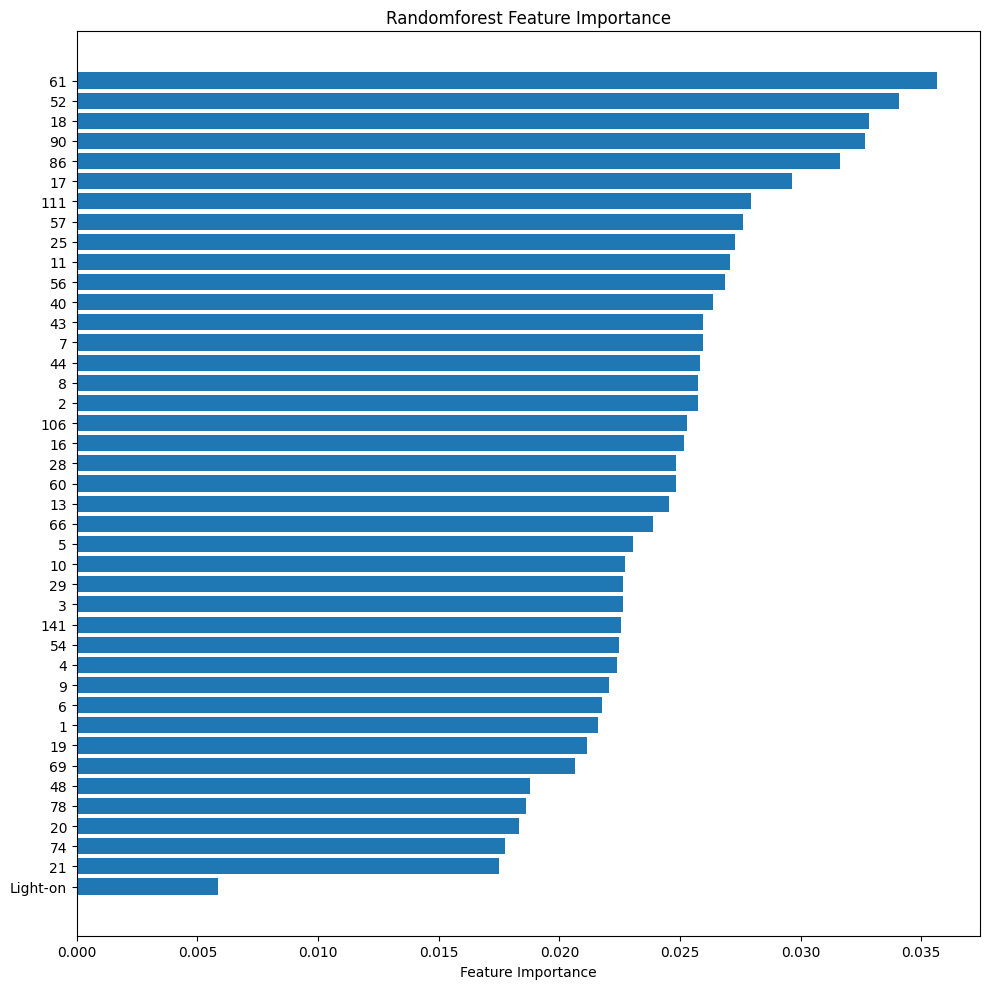

[0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 13, 15, 17, 18, 19, 20, 25, 32, 34, 37, 50, 5, 12, 16, 28, 39, 40, 41, 44, 52, 65, 73, 75, 80, 87, 97, 99, 101, 118, 146, 175, 186]
(12365, 44)
(12365, 44)
(1237, 44)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'max_depth': 19, 'max_features': 0.09997491581800289, 'min_samples_leaf': 8, 'min_samples_split': 6, 'n_estimators': 149}
Best r2 score: 0.0089
1115465
Test R2 score: -0.0473


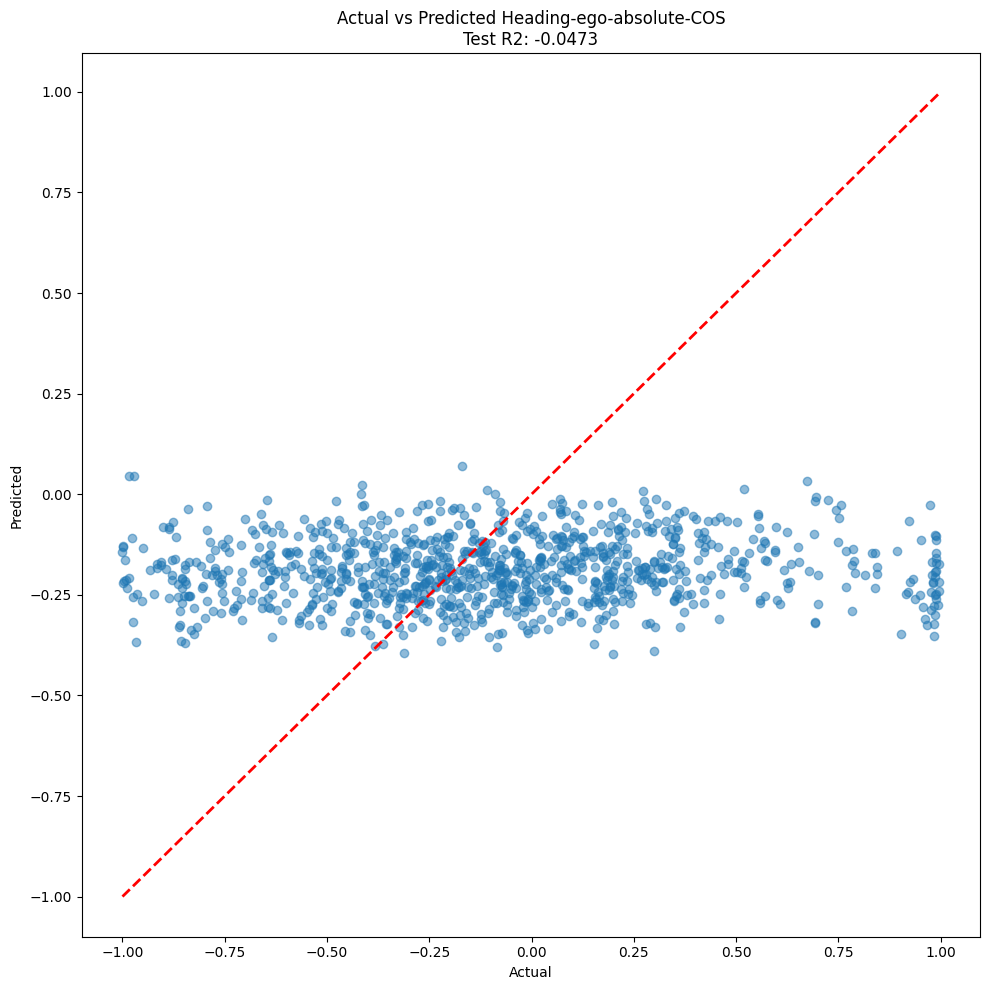

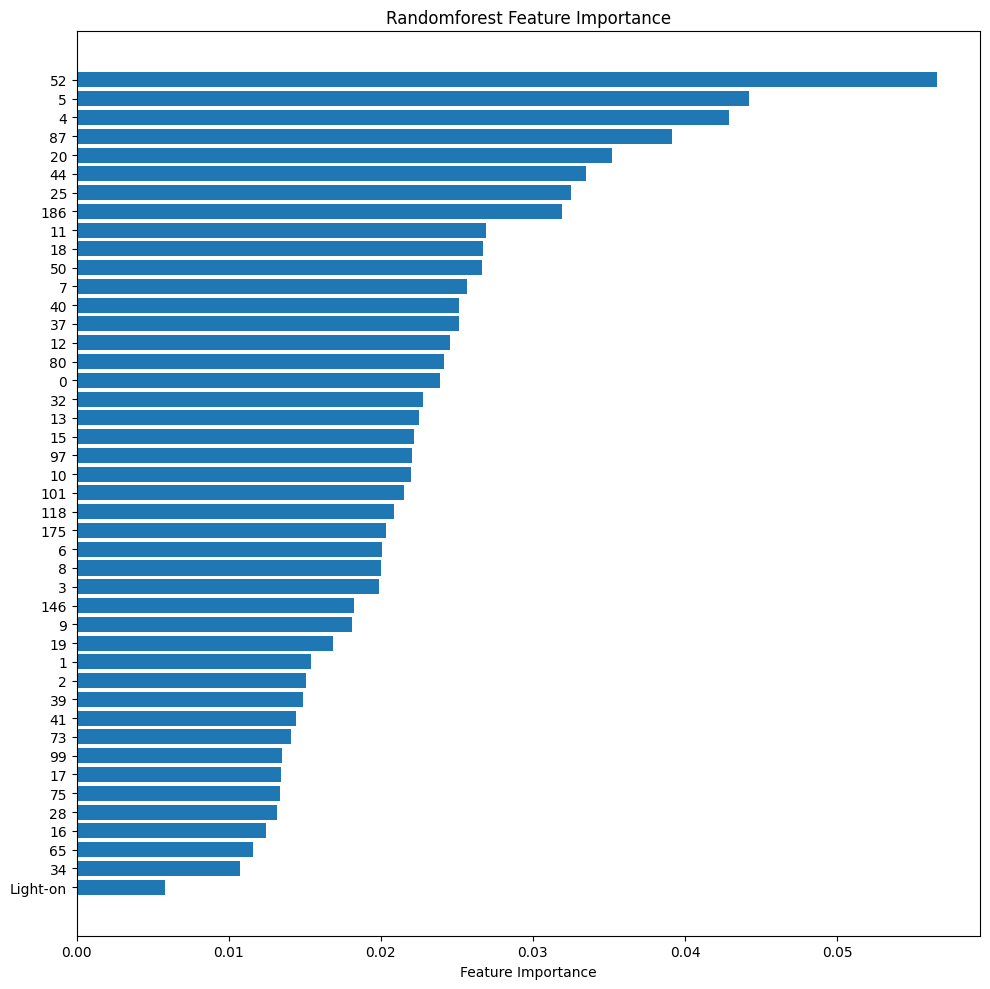

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 20, 23, 24, 26, 27, 29, 30, 33, 35, 31, 38, 40, 48, 50, 70, 80, 93, 109, 110]
(17782, 38)
(17782, 38)
(1779, 38)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'max_depth': 7, 'max_features': 0.7965429868602328, 'min_samples_leaf': 8, 'min_samples_split': 6, 'n_estimators': 152}
Best r2 score: 0.0309
1115464
Test R2 score: -0.0049


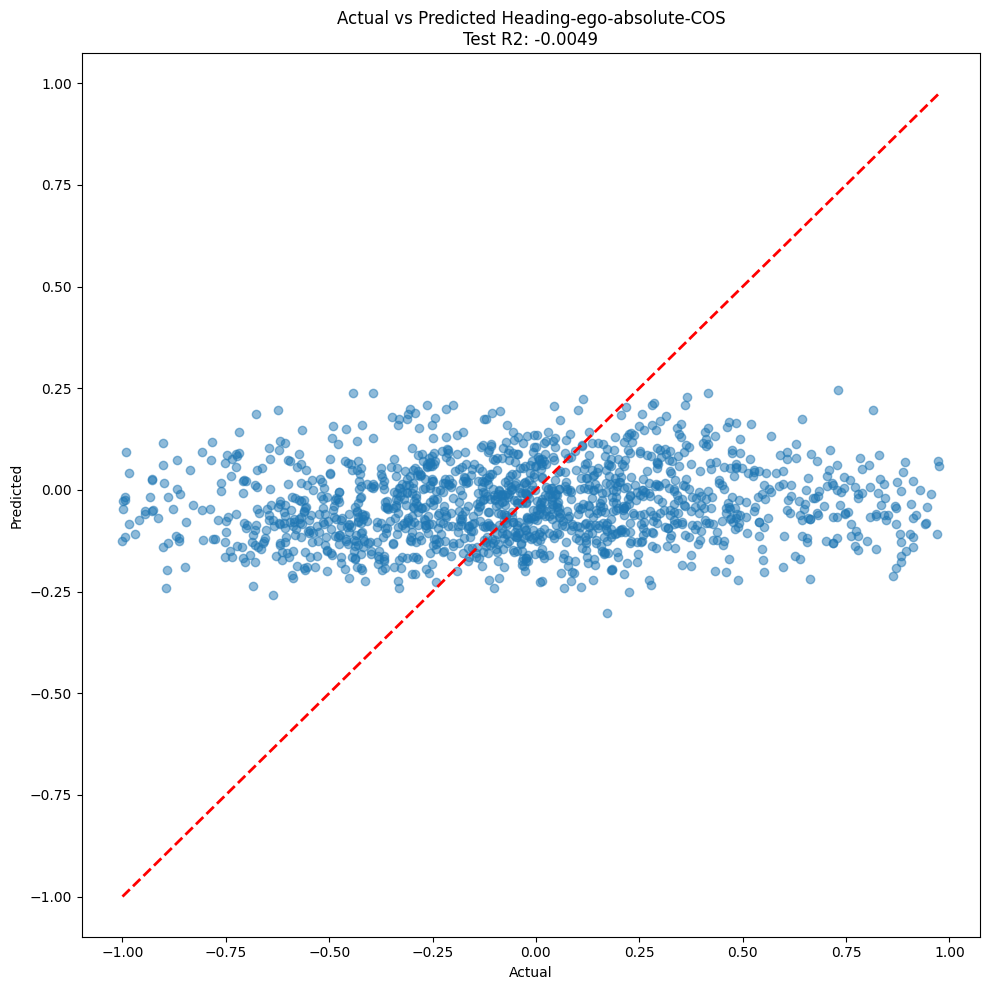

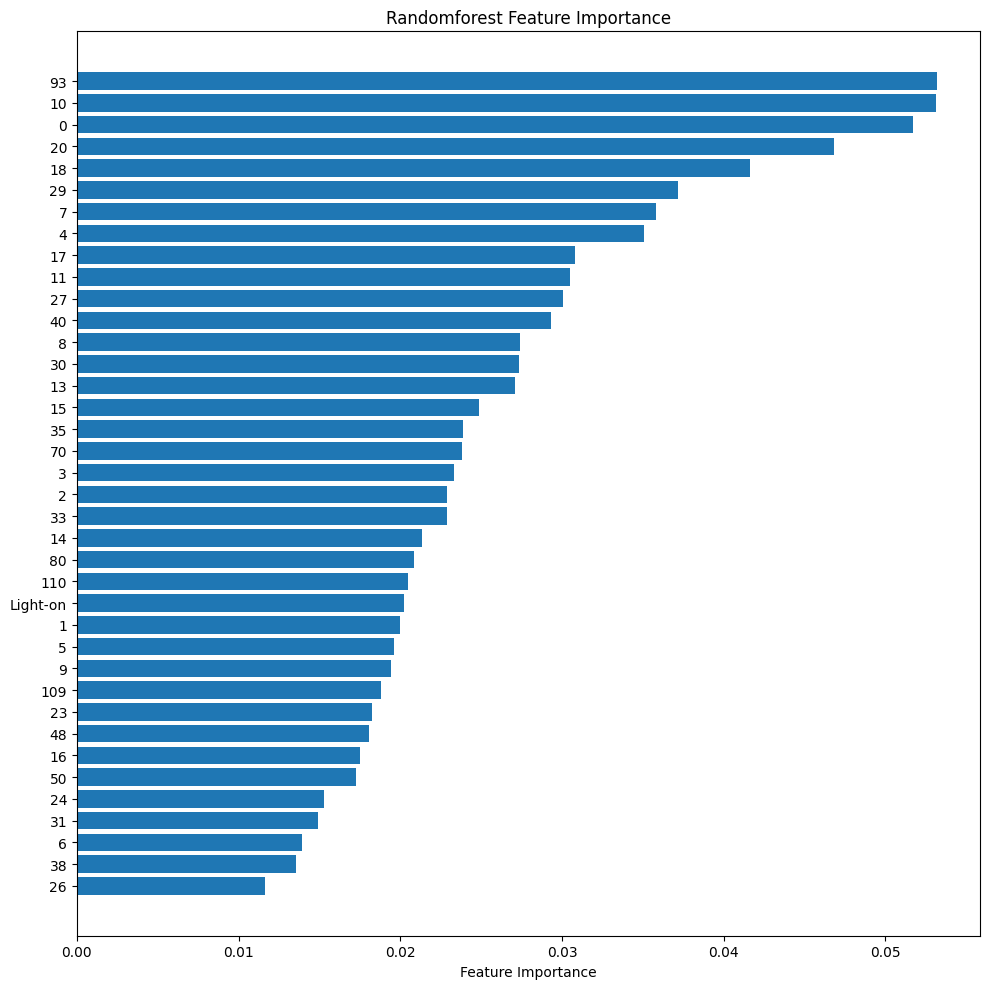

[0, 1, 2, 3, 4, 5, 6, 8, 9, 11, 13, 15, 19, 20, 26, 35, 44, 7, 16, 17, 18, 23, 29, 37, 45, 48, 50, 52, 53, 57, 60, 62, 65, 66, 71, 74, 75, 76, 87, 98, 118]
(10847, 42)
(10847, 42)
(1085, 42)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'max_depth': 10, 'max_features': 0.04666566321361543, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 293}
Best r2 score: -0.0419
1116663
Test R2 score: 0.0215


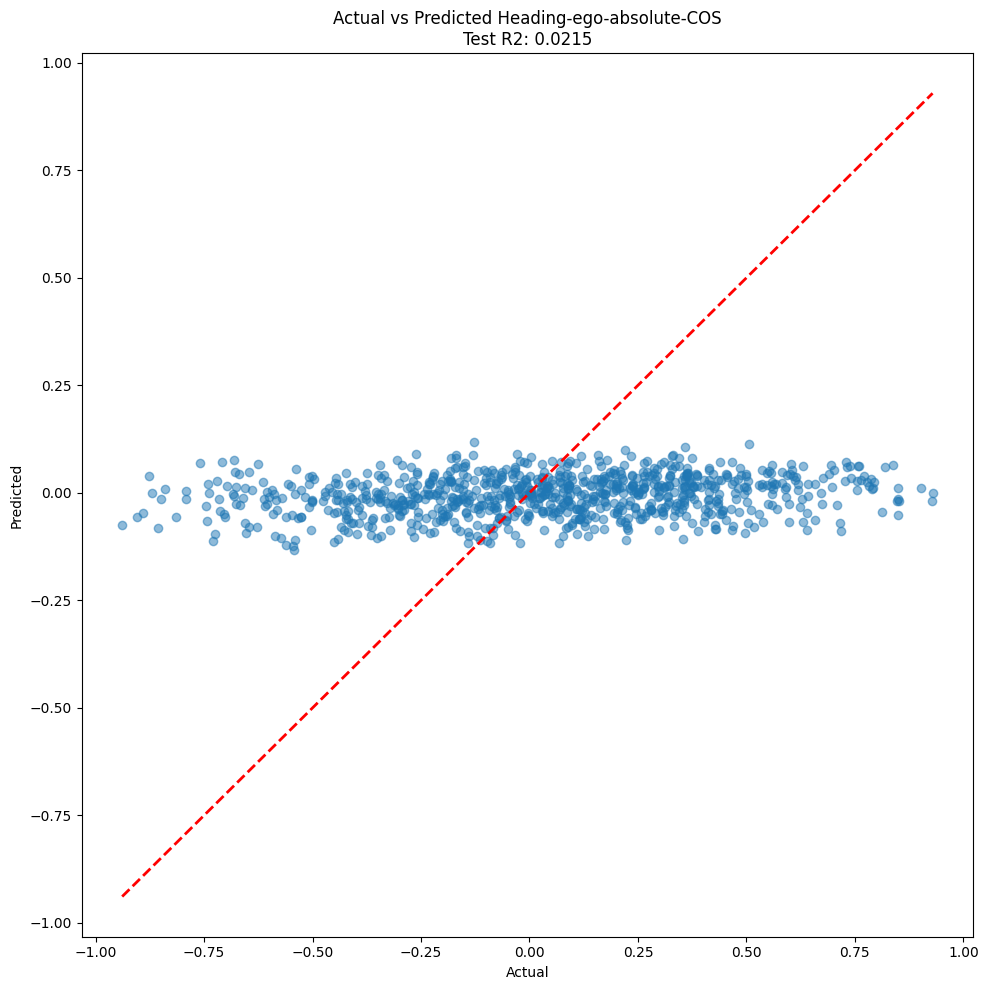

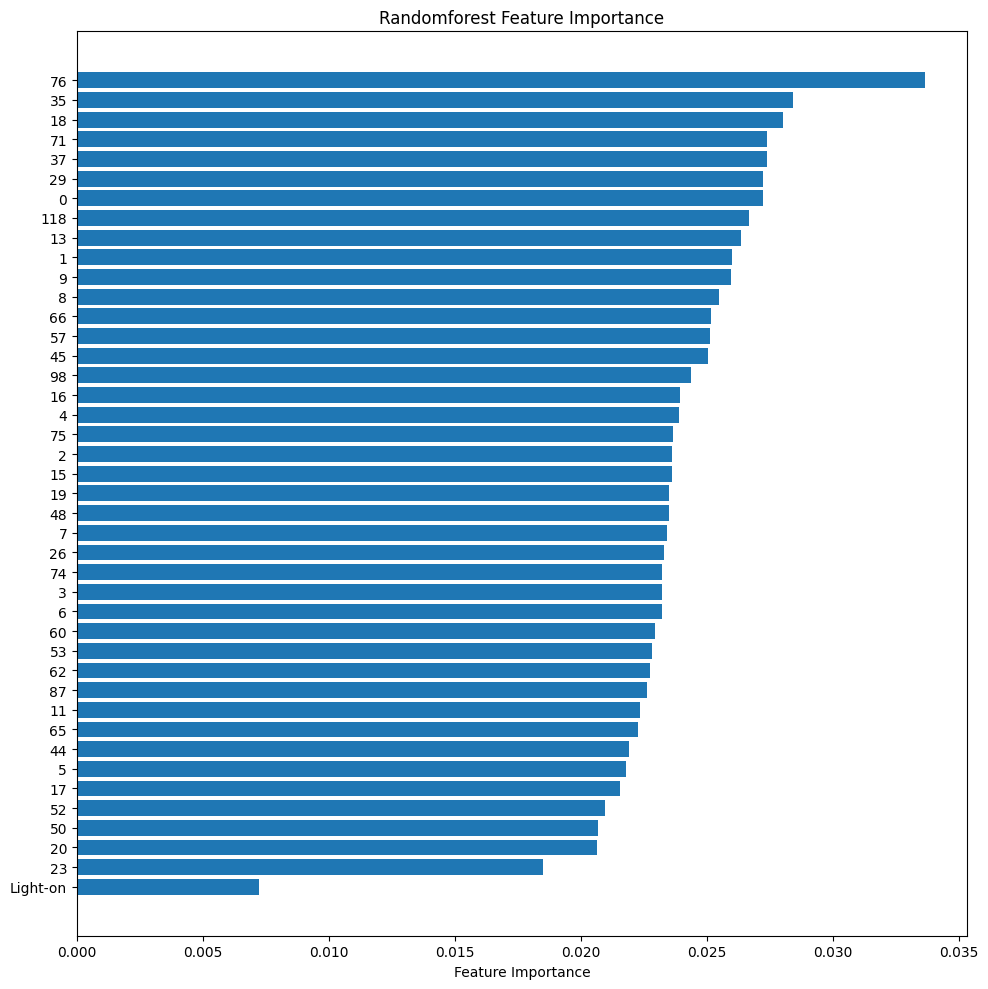

[1, 11]
(15755, 3)
(15755, 3)
(1576, 3)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'max_depth': 1, 'max_features': 0.6059599747810114, 'min_samples_leaf': 10, 'min_samples_split': 8, 'n_estimators': 90}
Best r2 score: -0.0618
1117217
Test R2 score: 0.0072


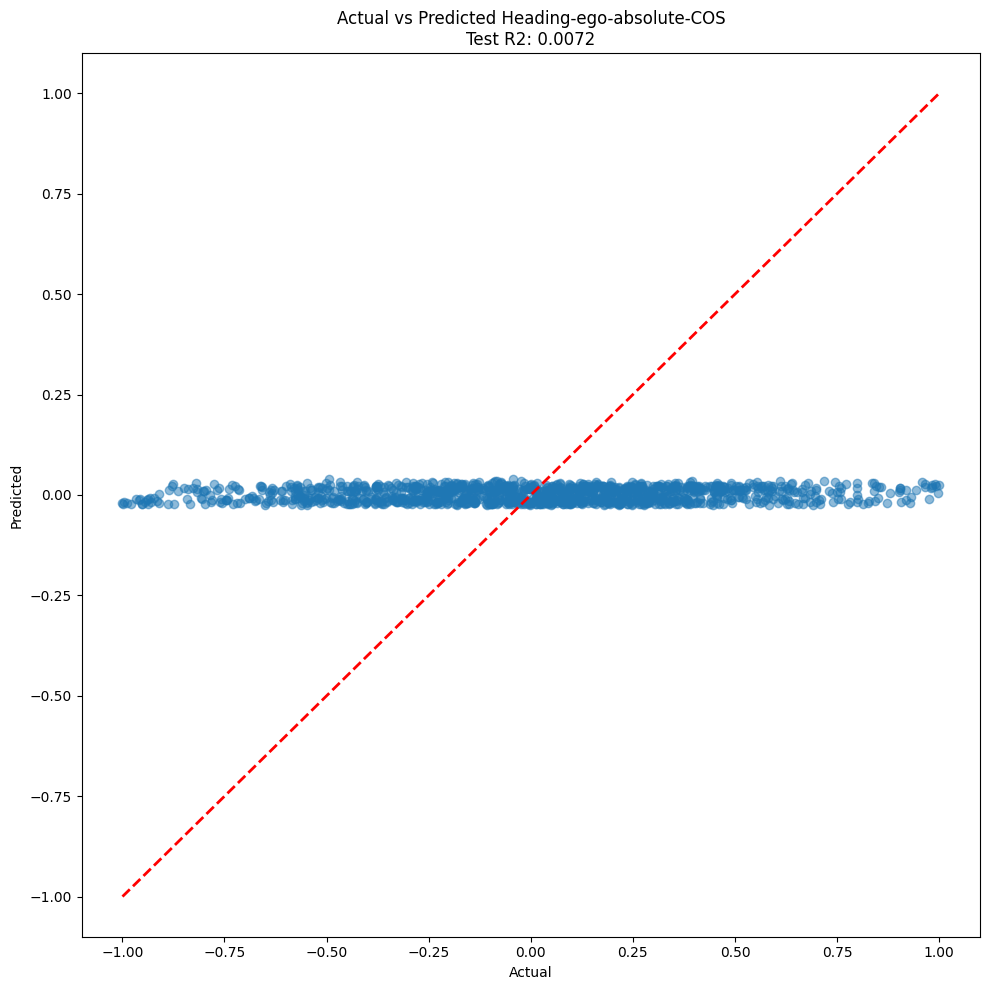

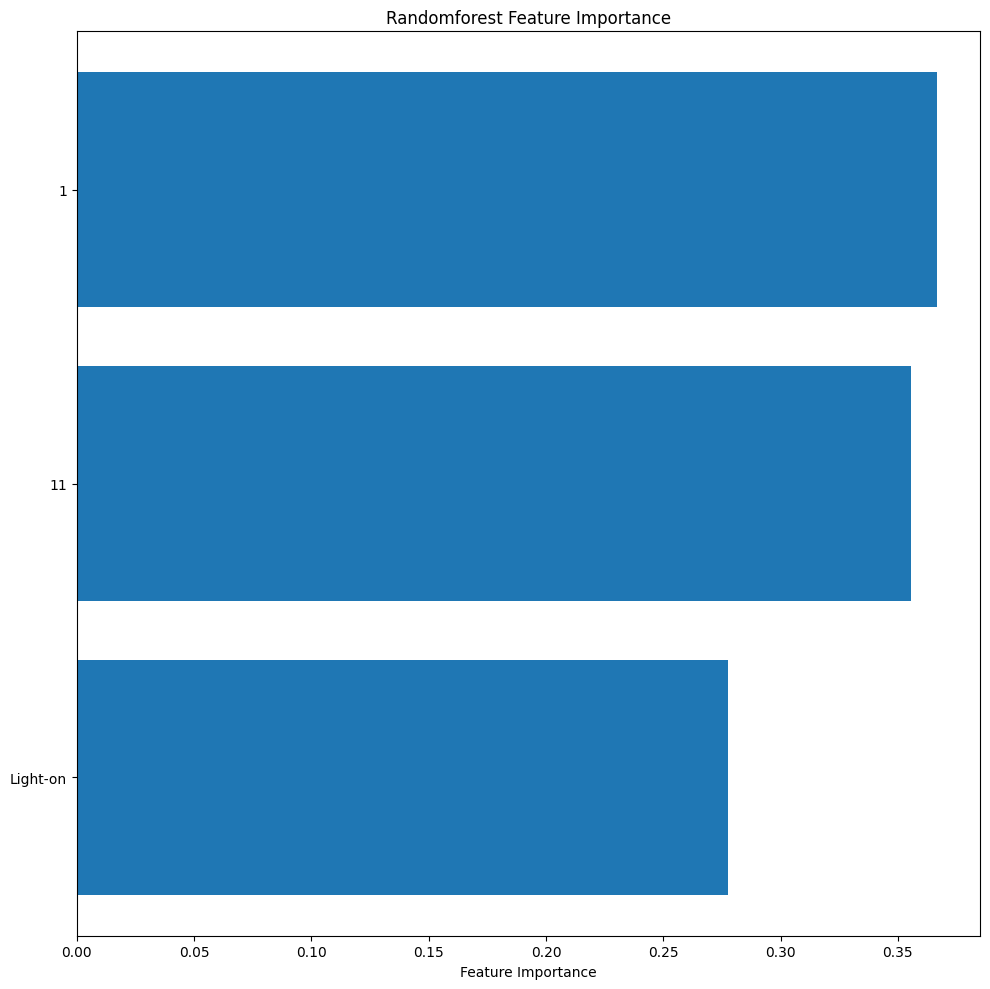

[0, 1, 2, 3, 4, 5, 7, 8, 13, 16, 27, 36]
(8208, 13)
(8208, 13)
(821, 13)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'max_depth': 10, 'max_features': 0.04666566321361543, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 293}
Best r2 score: -0.1054
1116994
Test R2 score: -0.0109


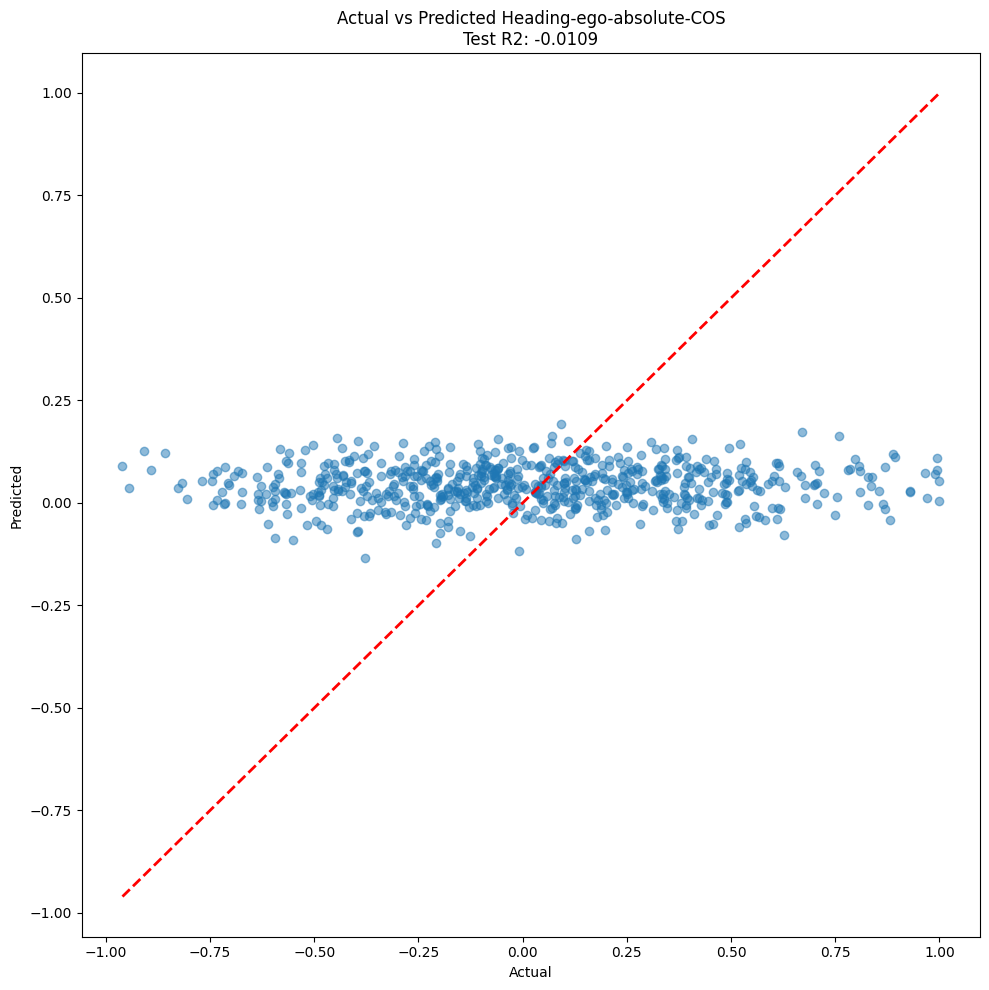

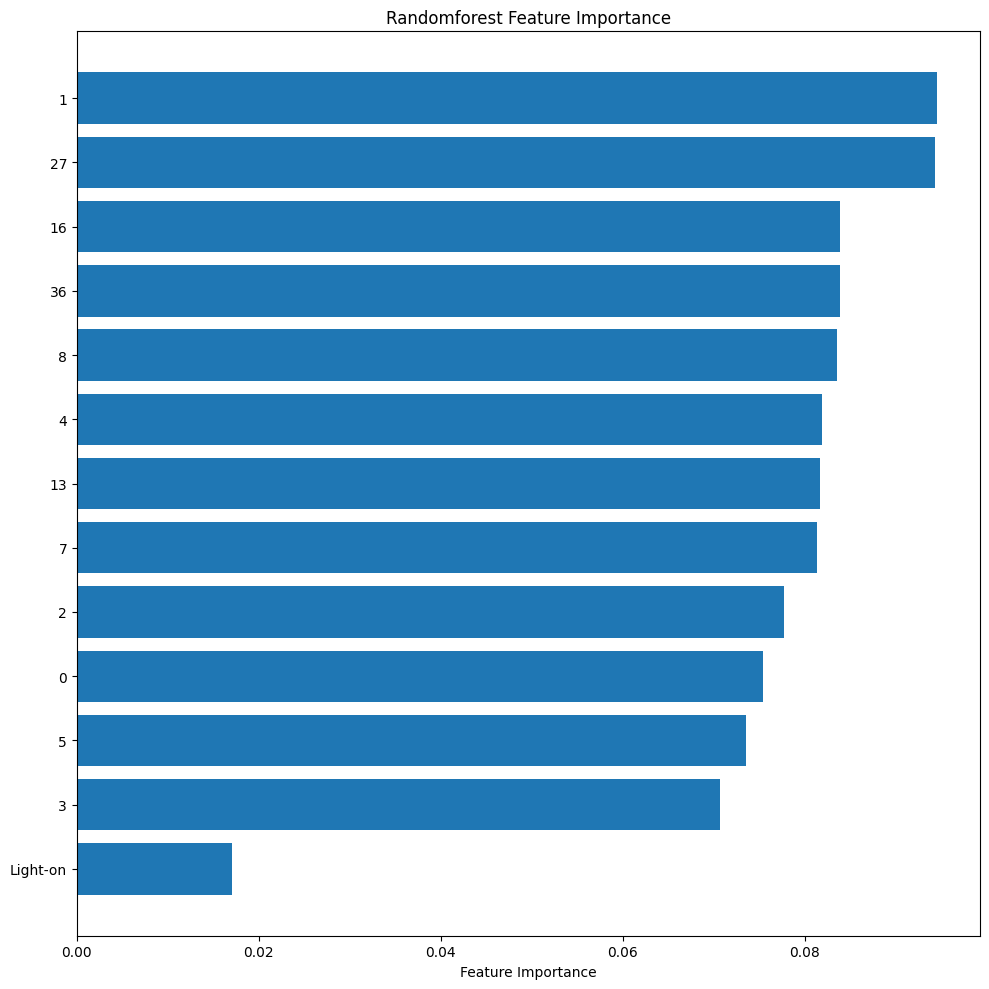

[0, 1, 2, 4, 5, 6, 8, 10, 12, 14, 15]
(10780, 12)
(10780, 12)
(1078, 12)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'max_depth': 10, 'max_features': 0.04666566321361543, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 293}
Best r2 score: 0.0019
1117646
Test R2 score: 0.0089


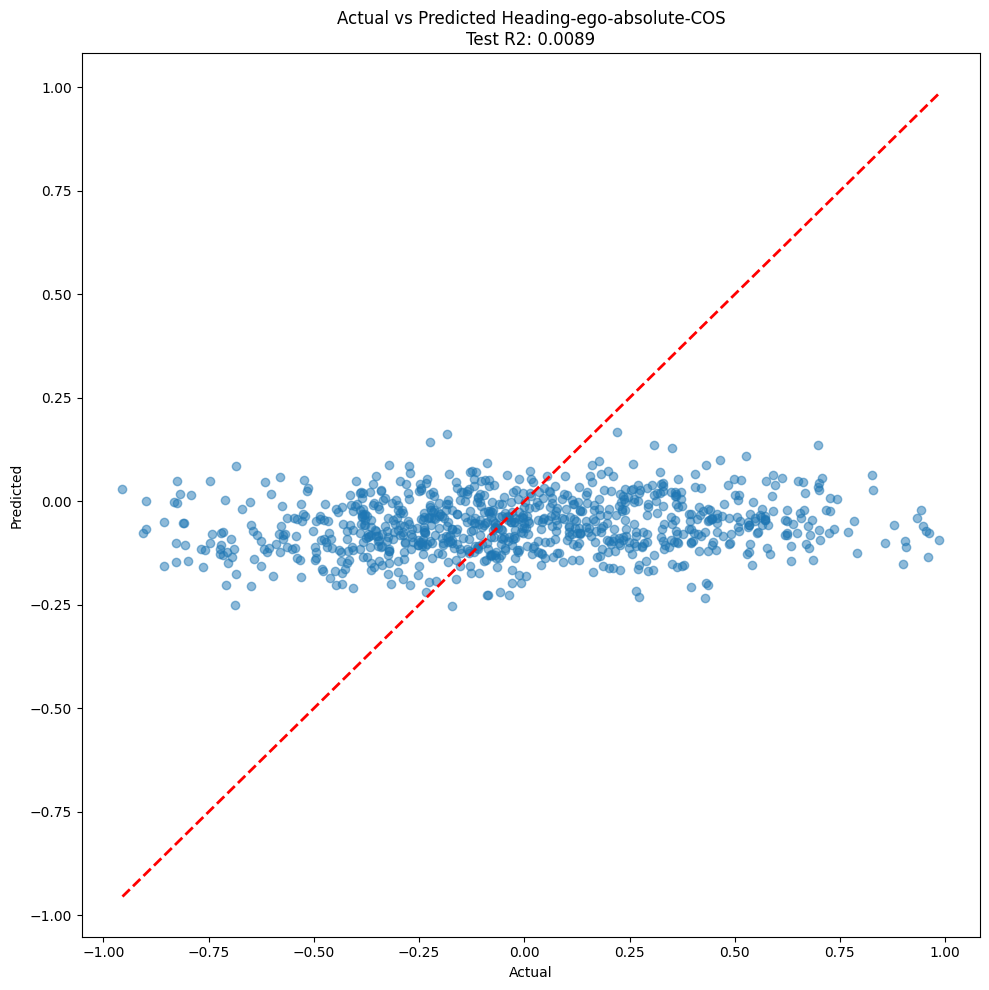

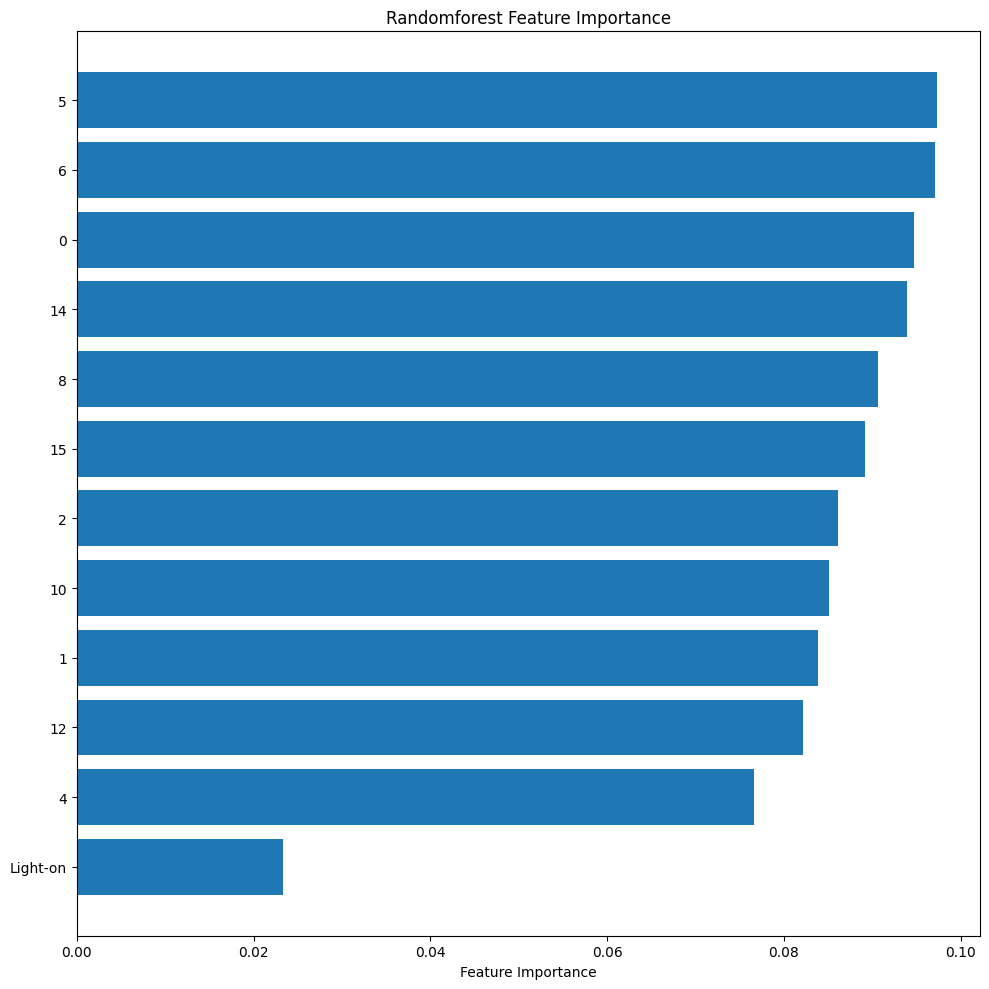

[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 15, 13, 17, 18, 25, 27, 36, 40, 48]
(17891, 20)
(17891, 20)
(1790, 20)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'max_depth': 7, 'max_features': 0.7965429868602328, 'min_samples_leaf': 8, 'min_samples_split': 6, 'n_estimators': 152}
Best r2 score: 0.0162
1118020
Test R2 score: 0.0103


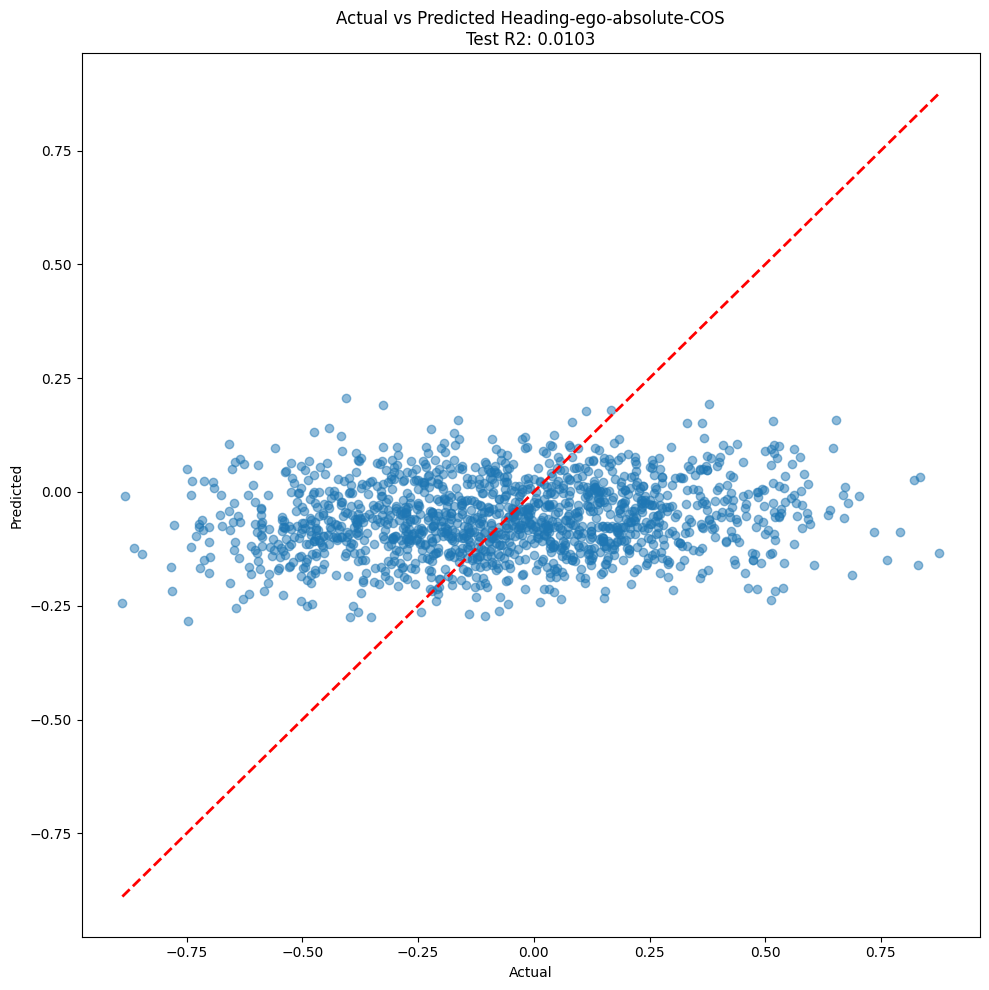

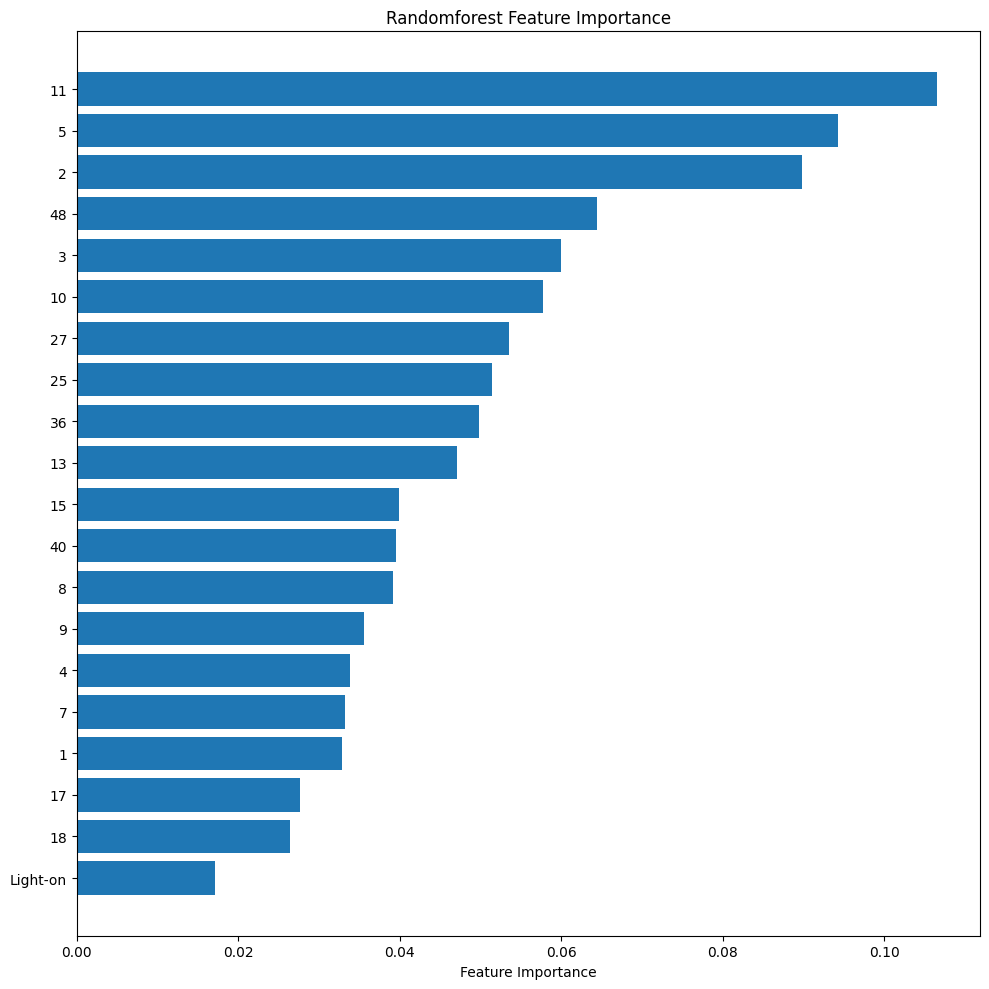

[0, 1, 2, 3, 6, 8, 9, 15, 26, 4, 12, 16, 33]
(11945, 14)
(11945, 14)
(1195, 14)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'max_depth': 7, 'max_features': 0.013264961159866528, 'min_samples_leaf': 9, 'min_samples_split': 3, 'n_estimators': 314}
Best r2 score: -0.0023
1117788
Test R2 score: 0.0254


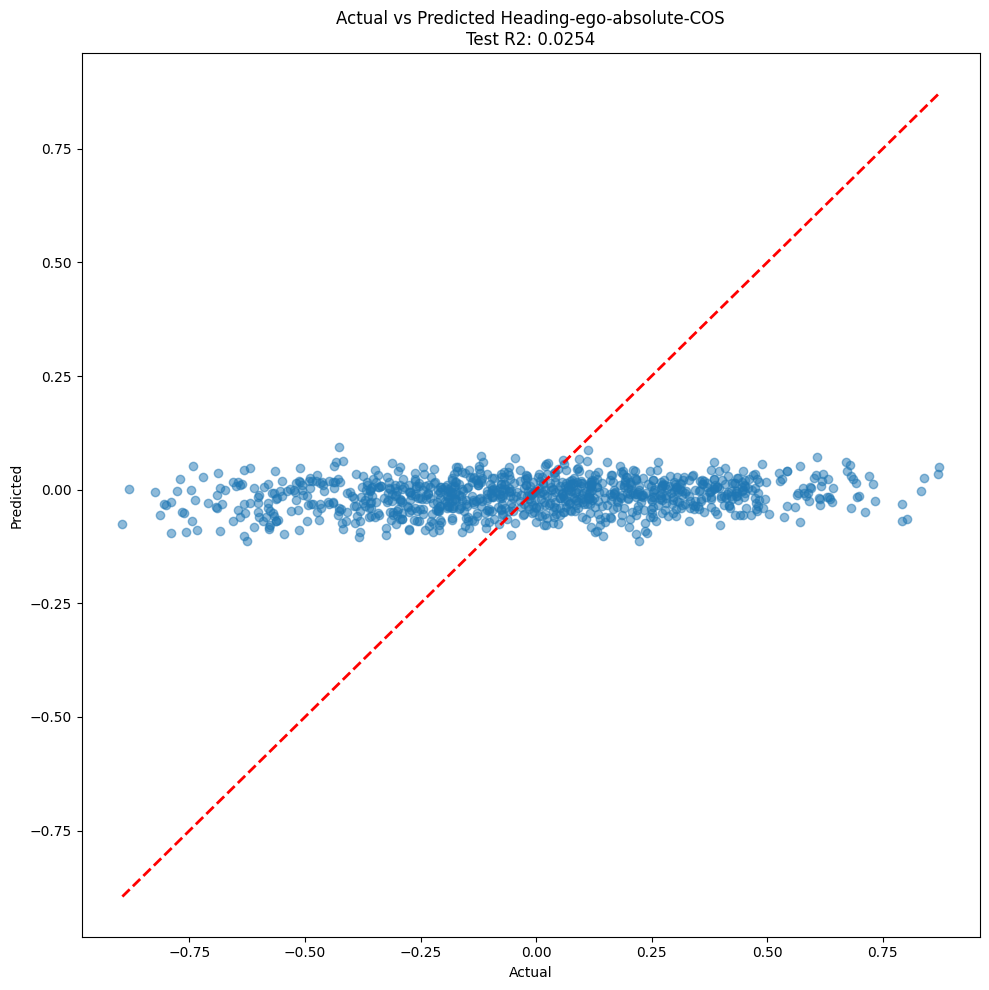

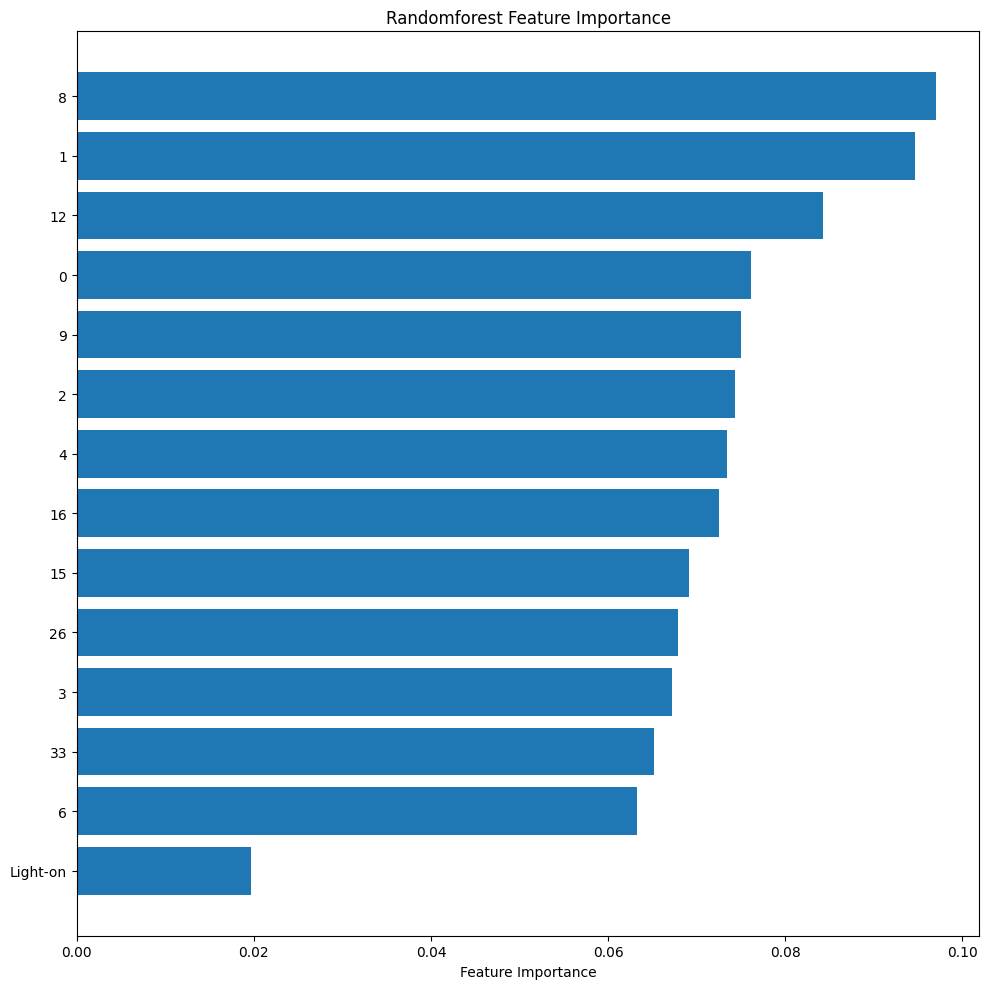

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 27, 36, 43, 14, 22, 25, 28, 29, 31, 37, 45, 57, 59, 62, 66, 104]
(17892, 38)
(17892, 38)
(1790, 38)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'max_depth': 3, 'max_features': 0.9093204020787821, 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 409}
Best r2 score: 0.0488
1118213
Test R2 score: 0.0622


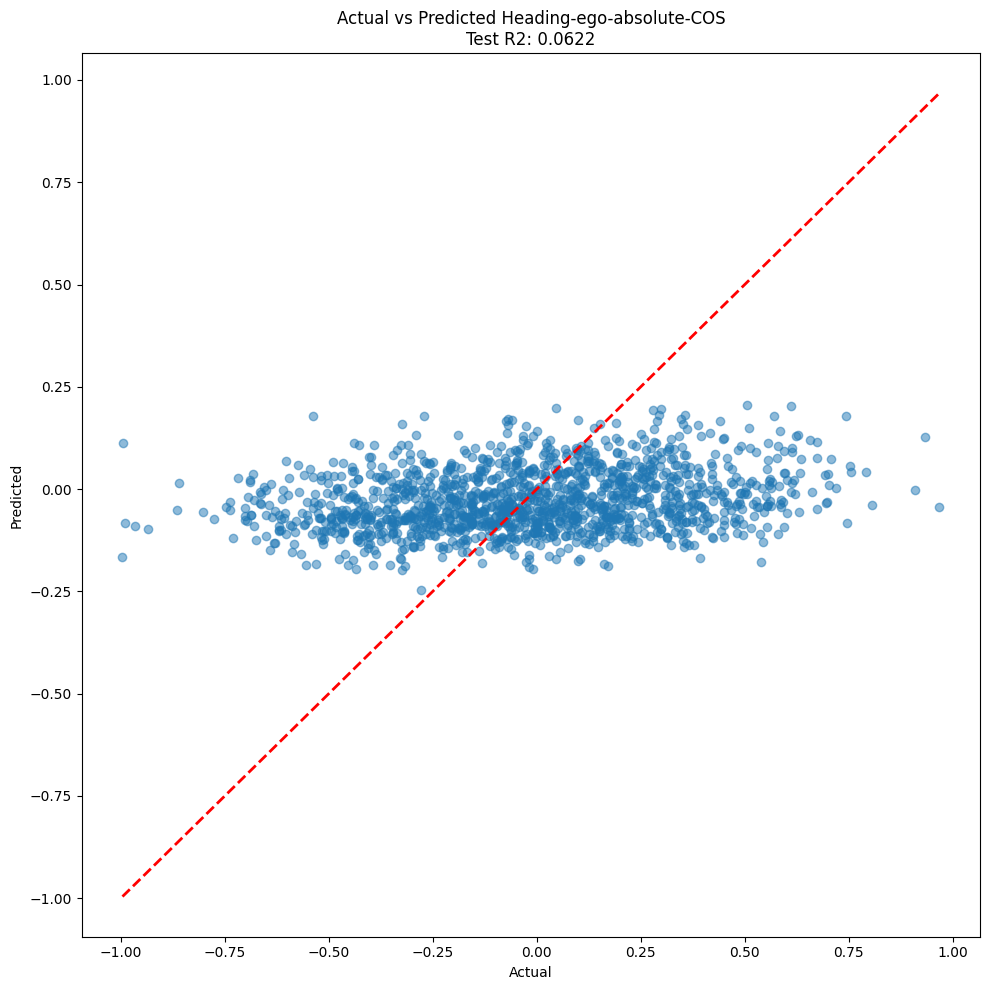

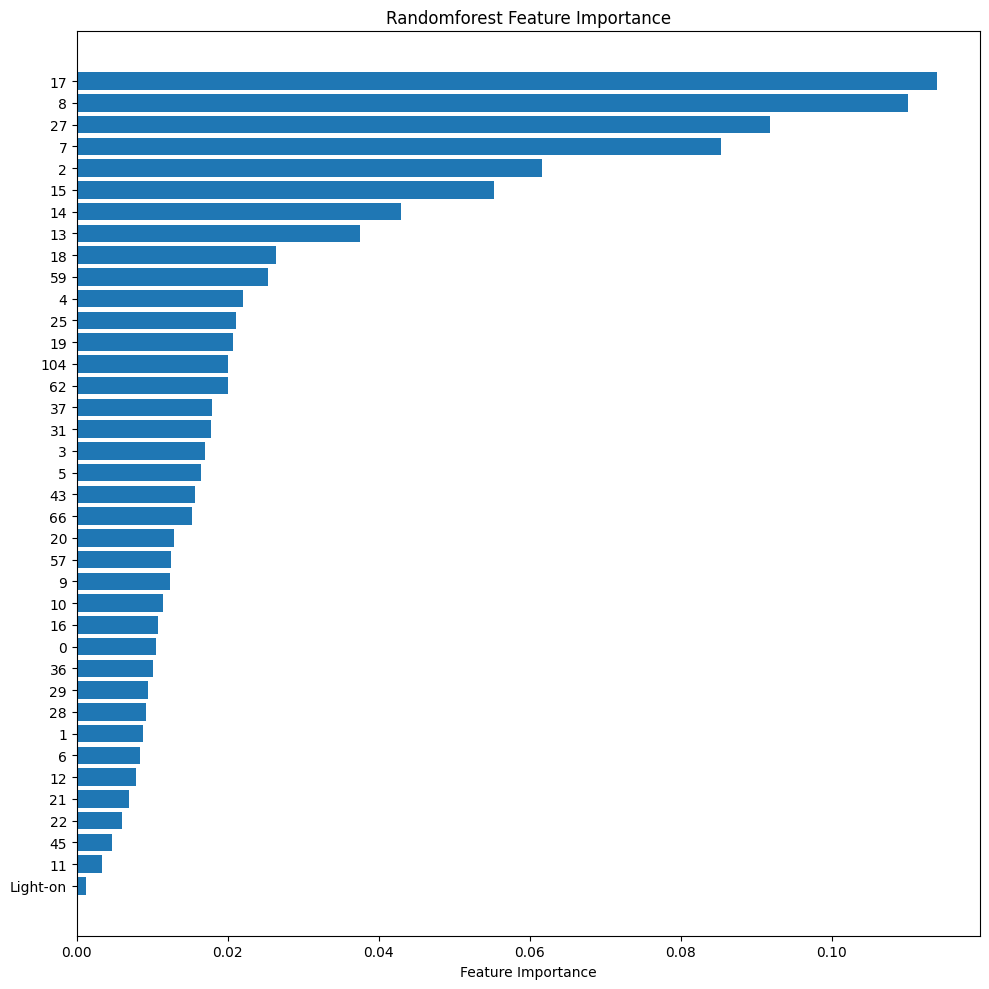

[0, 1, 2, 3, 4, 5, 8, 9, 12, 13, 15, 18, 26, 66, 79]
(17892, 16)
(17892, 16)
(1790, 16)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'max_depth': 4, 'max_features': 0.18485445552552704, 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 251}
Best r2 score: -0.0303
1118320
Test R2 score: 0.0098


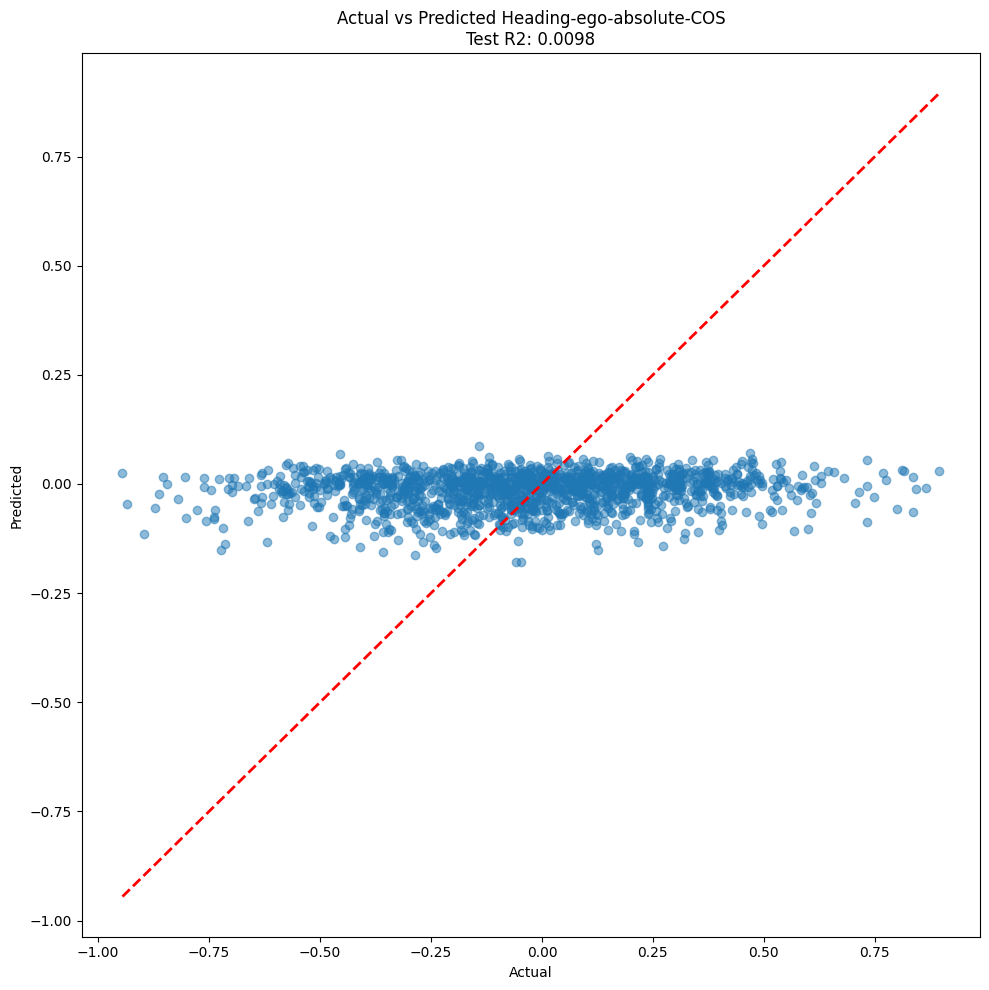

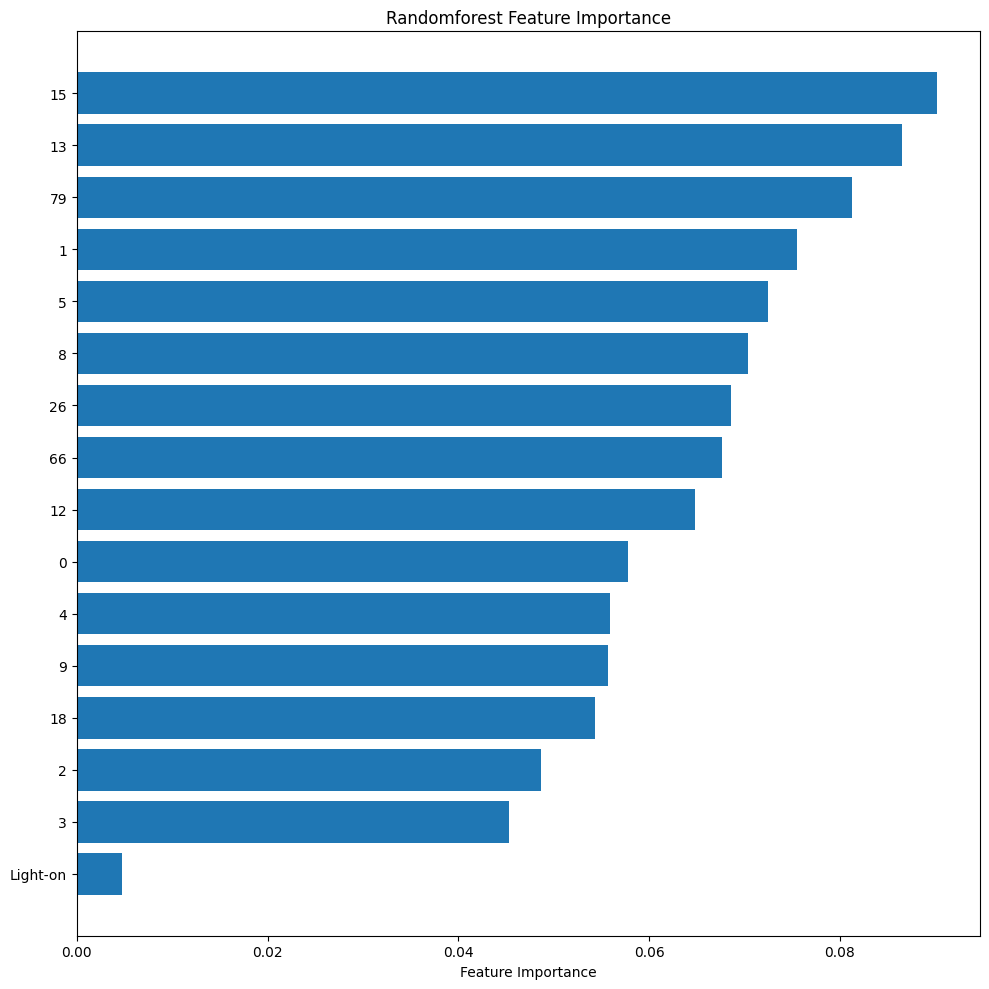

In [48]:
DO_HYPER_TUNING = True
MODEL_TYPE = 'randomforest'  # Options: 'xgboost', 'lightgbm', 'randomforest'
REMOVE_SILENCE = False
RESPONSE_TYPE = cu.CA_DECONV_NORM
TEST_ON_TRAIN = False
PLOT_PCA = True
SMOOTH_SIGMA = 10 # None
SMOOTH_STEP = SMOOTH_SIGMA
behave_predictors = [
                     bu.LIGHT_ON,
                     # bu.SPEED_FILT_GRAD,
                     # # COL_HD_SIN,
                     # # COL_HD_COS,
                     # # bu.HEAD_X_FILT_MAZE,
                     # # bu.HEAD_Y_FILT_MAZE
                     ]

DO_CLASSIFICATION = False  # Set this to True for classification, False for regression
TARGET = COL_HEADING_EGO_SIN
df_behave_ca_decode = df_behave_ca.copy(deep=True)
# df_behave_ca_decode = df_behave_ca.loc[bu.get_moving_indexes(df_behave_ca)].copy(deep=True)

# DO_CLASSIFICATION = True  # Set this to True for classification, False for regression
# TARGET = bu.HEAD_X_FILT_MAZE
# df_behave_ca_decode = df_behave_ca.copy(deep=True)


grp_df_exp = df_behave_ca_decode.groupby(['exp_id', 'animal_id', 'celltype'])

def run_model(x_train, x_test, y_train, y_test, do_hyper_tuning=False, do_classification=False, model_type='xgboost'):
    if model_type == 'xgboost':
        if do_classification:
            model_class = xgb.XGBClassifier
        else:
            model_class = xgb.XGBRegressor
    elif model_type == 'lightgbm':
        if do_classification:
            model_class = lgb.LGBMClassifier
        else:
            model_class = lgb.LGBMRegressor
    else:  # randomforest
        if do_classification:
            model_class = RandomForestClassifier
        else:
            model_class = RandomForestRegressor
    
    scoring = 'accuracy' if do_classification else 'r2'

    if do_hyper_tuning:
        if model_type == 'xgboost':
            param_dist = {
                'n_estimators': [100, 200, 300, 400, 500],
                'max_depth': [3, 4, 5, 6, 7, 8],
                'learning_rate': [0.01, 0.05, 0.1, 0.3],
                'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
                'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
                'min_child_weight': [1, 2, 3, 4, 5]
            }
        elif model_type == 'lightgbm':
            param_dist = {
                'n_estimators': [100, 200, 300, 400, 500],
                'max_depth': [-1, 3, 5, 7, 9],
                'learning_rate': [0.01, 0.05, 0.1, 0.3],
                'num_leaves': [31, 63, 127],
                'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
                'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
                'min_child_samples': [1, 5, 10, 20, 30]
            }
        else:  # randomforest
            param_dist = {
                'n_estimators': randint(50, 500),
                'max_depth': randint(1, 20),
                'min_samples_split': randint(2, 11),
                'min_samples_leaf': randint(1, 11),
                'max_features': uniform(0, 1)
            }

        model = model_class(random_state=42)

        random_search = RandomizedSearchCV(model, 
                                           param_distributions=param_dist, 
                                           n_iter=20, cv=5, 
                                           scoring=scoring, n_jobs=-1, 
                                           random_state=42, verbose=1)

        random_search.fit(x_train, y_train)

        best_model = random_search.best_estimator_
        
        print(f"Best parameters: {random_search.best_params_}")
        print(f"Best {scoring} score: {random_search.best_score_:.4f}")

        return best_model
    else:
        model = model_class(n_estimators=100, random_state=42)
        model.fit(x_train, y_train)
        return model

def plot_classification_results(y_test, pred_y, TARGET, accuracy):
    # Compute confusion matrix
    cm = confusion_matrix(y_test, pred_y)
    
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Confusion Matrix Heatmap
    im = ax1.imshow(cm, interpolation='nearest', cmap='Blues')
    ax1.set_xlabel('Predicted Class')
    ax1.set_ylabel('Actual Class')
    ax1.set_title('Confusion Matrix')
    
    # Add text annotations to the confusion matrix
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax1.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    
    # Add colorbar
    plt.colorbar(im, ax=ax1)
    
    # Actual vs Predicted scatter plot with jitter
    x_jitter = np.random.normal(0, 0.1, size=len(y_test))
    y_jitter = np.random.normal(0, 0.1, size=len(pred_y))
    
    ax2.scatter(y_test + x_jitter, pred_y + y_jitter, alpha=0.5)
    ax2.set_xlabel('Actual Class')
    ax2.set_ylabel('Predicted Class')
    ax2.set_title(f'Actual vs Predicted Class (with jitter)')
    
    # Set axis limits and ticks
    ax2.set_xlim(-0.5, 1.5)
    ax2.set_ylim(-0.5, 1.5)
    ax2.set_xticks([0, 1])
    ax2.set_yticks([0, 1])
    
    # Add a diagonal line
    ax2.plot([-0.5, 1.5], [-0.5, 1.5], 'r--', lw=2)
    
    # Add text annotation for accuracy
    ax2.text(0.05, 0.95, f'Accuracy: {accuracy:.4f}', transform=ax2.transAxes, 
             verticalalignment='top', fontsize=12, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
def plot_pca(X, y, x_train, x_test, do_classification):
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Perform PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # Create a DataFrame for easier plotting
    df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
    df_pca['target'] = y
    df_pca['is_train'] = df_pca.index.isin(x_train.index)

    # Plot
    plt.figure(figsize=(12, 8))
    
    if do_classification:
        colors = ['red', 'blue']
        for i, color in enumerate(colors):
            mask_train = (df_pca['is_train']) & (df_pca['target'] == i)
            mask_test = (~df_pca['is_train']) & (df_pca['target'] == i)
            
            plt.scatter(df_pca.loc[mask_train, 'PC1'], 
                        df_pca.loc[mask_train, 'PC2'],
                        c=color, marker='o', alpha=0.7, label=f'Train Class {i}')
            plt.scatter(df_pca.loc[mask_test, 'PC1'], 
                        df_pca.loc[mask_test, 'PC2'],
                        c=color, marker='x', alpha=0.7, label=f'Test Class {i}')
    else:
        scatter = plt.scatter(df_pca.loc[df_pca['is_train'], 'PC1'], 
                              df_pca.loc[df_pca['is_train'], 'PC2'],
                              c=df_pca.loc[df_pca['is_train'], 'target'], 
                              cmap='viridis', 
                              marker='o', 
                              alpha=0.7)
        plt.scatter(df_pca.loc[~df_pca['is_train'], 'PC1'], 
                    df_pca.loc[~df_pca['is_train'], 'PC2'],
                    c=df_pca.loc[~df_pca['is_train'], 'target'], 
                    cmap='viridis', 
                    marker='x', 
                    alpha=0.7)
        plt.colorbar(scatter, label='Target Value')

    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2f})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2f})')
    plt.title('PCA of Dataset')
    plt.legend()
    plt.tight_layout()
    plt.show()

for (exp_id, animal_id, cell_type), group in grp_df_exp:
    roi_id_list = group['roi_id'].unique().tolist()
    print(roi_id_list)
    
    df_pivot = group.pivot_table(index='frame_id',
                                 columns='roi_id',
                                 values=RESPONSE_TYPE, 
                                 aggfunc='first')
    
    df_pivot = df_pivot[roi_id_list]
    
    
    first_roi_id = group['roi_id'].iloc[0]
    
    # Check if target is an int, then it's a roi
    if isinstance(TARGET, int):
        target_values = df_pivot[TARGET]
    else:   
        target_values = group[group['roi_id'] == first_roi_id][TARGET]
    
    # Extract additional predictor values
    for col in behave_predictors:
        if col == TARGET:
            continue
        df_pivot[col] = group[group['roi_id'] == first_roi_id][col].values
        
    # Remove any rois if they are the target
    for col in roi_id_list:
        if col == TARGET:
            roi_id_list.remove(col)
            df_pivot.drop(col, axis=1, inplace=True)
            break

    print(df_pivot.shape)
    
    print(df_pivot.shape)
    if SMOOTH_SIGMA is not None:
        df_pivot = df_pivot.rolling(window=SMOOTH_SIGMA, min_periods=1, axis=0, step=SMOOTH_STEP).mean()
        target_values = target_values.rolling(window=SMOOTH_SIGMA, min_periods=1, step=SMOOTH_STEP).mean()
        if DO_CLASSIFICATION:
            # Convert back to binary
            target_values = np.int64(np.round(target_values))
        
    print(df_pivot.shape)  
    
    if REMOVE_SILENCE:
        silent_indexes = (df_pivot[roi_id_list] == 0).all(axis=1)
        df_pivot = df_pivot[~silent_indexes]
        target_values = target_values[~silent_indexes]
        print(df_pivot.shape)
        
    df_pivot.columns = df_pivot.columns.astype(str)
    
    

    x_train, x_test, y_train, y_test = train_test_split(df_pivot, 
                                                        target_values,                              
                                                        test_size=0.8, 
                                                        random_state=42)

    # Plot PCA
    # if PLOT_PCA:
    #     plot_pca(df_pivot, target_values, x_train, x_test, DO_CLASSIFICATION)

    best_model = run_model(x_train, x_test, y_train, y_test, DO_HYPER_TUNING, DO_CLASSIFICATION, MODEL_TYPE)

    
    x_vals = x_test
    y_vals = y_test
    if TEST_ON_TRAIN:
        x_vals = x_train
        y_vals = y_train
    pred_y = best_model.predict(x_vals)

    print(animal_id)
    if DO_CLASSIFICATION:
        accuracy = accuracy_score(y_vals, pred_y)
        print(f"Test Accuracy score: {accuracy:.4f}")
        print(classification_report(y_test, pred_y))
        
        plot_classification_results(y_test, pred_y, TARGET, accuracy)
    else:
        r2 = r2_score(y_vals, pred_y)
        print(f"Test R2 score: {r2:.4f}")
        
        plt.figure(figsize=(10, 10))
        plt.scatter(y_vals, pred_y, alpha=0.5)
        plt.plot([y_vals.min(), y_vals.max()], [y_vals.min(), y_vals.max()], 'r--', lw=2)
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.title(f'Actual vs Predicted {TARGET}\nTest R2: {r2:.4f}')

    plt.tight_layout()
    plt.show()
    
    # Feature importance
    feature_importance = best_model.feature_importances_
    feature_names = df_pivot.columns
    sorted_idx = np.argsort(feature_importance)
    plt.figure(figsize=(10, 10))
    plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
    plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
    plt.xlabel('Feature Importance')
    plt.title(f'{MODEL_TYPE.capitalize()} Feature Importance')
    plt.tight_layout()
    plt.show()
    
    #break

In [ ]:

df_pivot.head(100)

In [61]:
target_values = group[group['roi_id'] == 2][['frame_id', TARGET]]
print(target_values)

        frame_id  Head-direction-absolute-filt-SIN
1              0                          0.817764
41             1                          0.555070
81             2                          0.177535
121            3                          0.004223
161            4                         -0.012858
...          ...                               ...
380361     15619                          0.518216
380401     15620                          0.578816
380441     15621                          0.531532
380481     15622                          0.636069
380521     15623                          0.586724

[8600 rows x 2 columns]


In [99]:
target_values

array([1, 1, 1, ..., 1, 1, 1])